# GreenXchange Plant Recommendation — Fixed ML Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

## Load Dataset

In [2]:
df = pd.read_csv('greenxchange_dataset_20000_clean.csv')
print('Shape:', df.shape)
df.head()

Shape: (20000, 25)


,AreaType,AQI,PM2.5,PM10,NO2,SO2,CO,O3,TrafficDensity,RoadDistance,...,Sunlight,SoilType,SoilPH,Drainage,SpaceType,AreaSize,MaintenanceLevel,WateringPreference,Purpose,RecommendedPlant
0,Residential,54,25.1,52.2,10.3,7.7,0.18,70.6,Medium,106,...,Full Shade,Loamy,6.1,Good,Indoor,Medium,Medium,Regular,Decoration,Peace Lily
1,Urban,52,28.8,53.8,4.5,2.8,0.66,32.4,Low,83,...,Full Sun,Sandy,7.0,Moderate,Outdoor,Large,High,Regular,Edible,Coconut
2,Residential,53,34.0,61.9,6.0,6.0,0.57,62.1,High,106,...,Full Shade,Loamy,7.9,Good,Indoor,Medium,High,Regular,Decoration,Peace Lily
3,Urban,67,15.7,33.9,3.8,5.5,0.36,78.2,Low,88,...,Partial Shade,Loamy,5.9,Good,Outdoor,Large,Medium,Regular,Edible,Mango
4,Residential,103,19.6,37.0,12.6,3.3,0.48,31.8,Low,93,...,Partial Shade,Loamy,7.7,Good,Indoor,Medium,Low,Frequent,Decoration,Snake Plant


## EDA

In [3]:
df.describe()

,AQI,PM2.5,PM10,NO2,SO2,CO,O3,RoadDistance,DustIndex,Temperature,Humidity,Rainfall,WindSpeed,SoilPH
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,67.131850,25.919260,51.863710,10.500470,4.255535,0.449992,59.883965,77.034050,54.485650,27.982250,61.932200,222.973750,10.029050,6.597890
std,21.946023,9.857675,19.991404,5.486984,2.171812,0.202355,17.249053,42.069401,25.903813,7.754272,18.781023,100.897662,6.054861,0.926918
min,30.000000,8.800000,16.000000,1.000000,0.500000,0.100000,30.000000,5.000000,10.000000,15.000000,30.000000,50.000000,0.000000,5.000000
25%,48.000000,17.400000,34.600000,5.800000,2.400000,0.270000,44.900000,40.000000,32.000000,21.000000,46.000000,135.000000,5.000000,5.800000
50%,67.000000,25.800000,51.450000,10.500000,4.300000,0.450000,60.000000,77.000000,55.000000,28.000000,62.000000,223.000000,10.000000,6.600000
75%,86.000000,34.300000,68.600000,15.200000,6.100000,0.630000,74.800000,113.000000,77.000000,35.000000,78.000000,311.000000,15.000000,7.400000
max,105.000000,43.100000,94.500000,20.000000,8.000000,0.800000,90.000000,149.000000,99.000000,41.000000,94.000000,399.000000,20.000000,8.200000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   AreaType            20000 non-null  str    
 1   AQI                 20000 non-null  int64  
 2   PM2.5               20000 non-null  float64
 3   PM10                20000 non-null  float64
 4   NO2                 20000 non-null  float64
 5   SO2                 20000 non-null  float64
 6   CO                  20000 non-null  float64
 7   O3                  20000 non-null  float64
 8   TrafficDensity      20000 non-null  str    
 9   RoadDistance        20000 non-null  int64  
 10  DustIndex           20000 non-null  int64  
 11  Temperature         20000 non-null  int64  
 12  Humidity            20000 non-null  int64  
 13  Rainfall            20000 non-null  int64  
 14  WindSpeed           20000 non-null  int64  
 15  Sunlight            20000 non-null  str    
 16  SoilType       

In [5]:
print('Null values:')
print(df.isnull().sum())

Null values:
AreaType              0
AQI                   0
PM2.5                 0
PM10                  0
NO2                   0
SO2                   0
CO                    0
O3                    0
TrafficDensity        0
RoadDistance          0
DustIndex             0
Temperature           0
Humidity              0
Rainfall              0
WindSpeed             0
Sunlight              0
SoilType              0
SoilPH                0
Drainage              0
SpaceType             0
AreaSize              0
MaintenanceLevel      0
WateringPreference    0
Purpose               0
RecommendedPlant      0
dtype: int64


Target class distribution:
RecommendedPlant
Areca Palm       2698
Bamboo           2681
Snake Plant      2492
Neem             1865
Mango            1373
Spider Plant     1219
Bougainvillea    1185
Peace Lily       1169
Tulsi            1070
Guava             950
Coconut           638
Banyan            632
Ashoka            623
Money Plant       622
Aloe Vera         500
Peepal            165
ZZ Plant          118
Name: count, dtype: int64


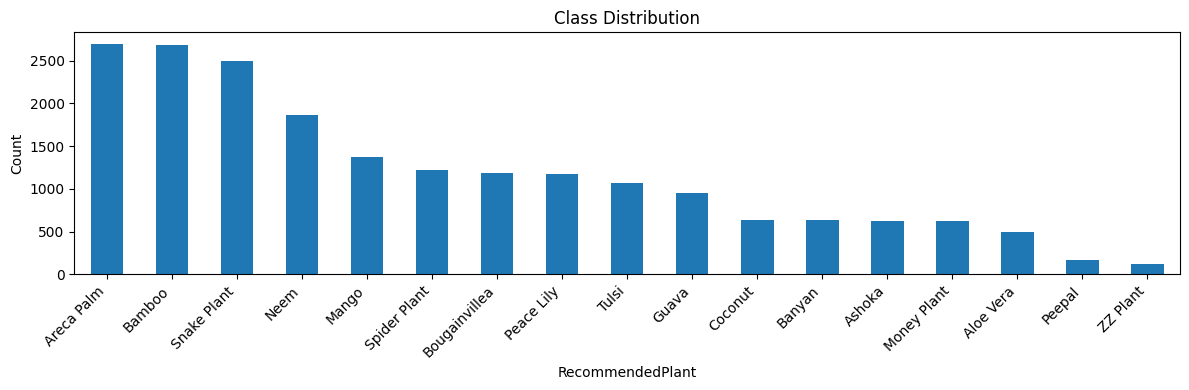

In [6]:
print('Target class distribution:')
print(df['RecommendedPlant'].value_counts())

plt.figure(figsize=(12, 4))
df['RecommendedPlant'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Split Features and Target

In [7]:
X = df.drop('RecommendedPlant', axis=1)
y = df['RecommendedPlant']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (20000, 24)
y shape: (20000,)


## Encode Target Variable

**Fix:** Use a dedicated LabelEncoder for the target `y`, separate from the feature encoders.

In [8]:
# FIX: Dedicated encoder for target — never reuse the feature encoder
le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)

print('Encoded classes:', le_target.classes_)
print('Sample encoded values:', y_encoded[:5])

Encoded classes: ['Aloe Vera' 'Areca Palm' 'Ashoka' 'Bamboo' 'Banyan' 'Bougainvillea'
 'Coconut' 'Guava' 'Mango' 'Money Plant' 'Neem' 'Peace Lily' 'Peepal'
 'Snake Plant' 'Spider Plant' 'Tulsi' 'ZZ Plant']
Sample encoded values: [11  6 11  8 13]


## Define Feature Columns

Separate columns into numeric, nominal categorical, and ordinal categorical (which have a meaningful order).

In [9]:
# Numeric features — will be scaled
numeric_cols = [
    'AQI', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'O3',
    'RoadDistance', 'DustIndex', 'Temperature', 'Humidity',
    'Rainfall', 'WindSpeed', 'SoilPH'
]

# Nominal categorical — no inherent order, use LabelEncoder
nominal_cols = ['AreaType', 'SoilType', 'SpaceType', 'Purpose']

# FIX: Ordinal categorical — encode with explicit meaningful order
ordinal_cols_config = [
    ('TrafficDensity',      ['Low', 'Medium', 'High']),
    ('Sunlight',            ['Full Shade', 'Partial Shade', 'Full Sun']),
    ('Drainage',            ['Poor', 'Moderate', 'Good']),
    ('AreaSize',            ['Small', 'Medium', 'Large']),
    ('MaintenanceLevel',    ['Low', 'Medium', 'High']),
    ('WateringPreference',  ['Rare', 'Regular', 'Frequent']),
]

ordinal_cols   = [c for c, _ in ordinal_cols_config]
ordinal_orders = [order for _, order in ordinal_cols_config]

print('Numeric cols:',  len(numeric_cols))
print('Nominal cols:',  len(nominal_cols))
print('Ordinal cols:',  len(ordinal_cols))

Numeric cols: 14
Nominal cols: 4
Ordinal cols: 6


## Train / Test Split

**Fix:** Use `stratify=y_encoded` to ensure rare classes appear proportionally in both train and test sets.

In [10]:
# FIX: stratify=y_encoded ensures rare classes are represented in both splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded   # <-- FIX
)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')

Train: 16000 rows | Test: 4000 rows


## Build Preprocessing Pipeline

**Fix:** Use `ColumnTransformer` inside a `Pipeline` so preprocessing is fitted only on train data (prevents data leakage). Numeric features are scaled, ordinal features use correct ordering, nominal features use LabelEncoder.

In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.base import BaseEstimator, TransformerMixin

# Sklearn's ColumnTransformer doesn't support LabelEncoder directly,
# so we use OrdinalEncoder for nominal cols too (same numeric result,
# but fits cleanly into a Pipeline)

preprocessor = ColumnTransformer(transformers=[
    ('num',     StandardScaler(),                                          numeric_cols),
    ('nom',     OrdinalEncoder(handle_unknown='use_encoded_value',
                               unknown_value=-1),                          nominal_cols),
    ('ord',     OrdinalEncoder(categories=ordinal_orders,
                               handle_unknown='use_encoded_value',
                               unknown_value=-1),                          ordinal_cols),
])

## Train and Evaluate Models

**Fixes applied:**
- Each model wrapped in a Pipeline with the preprocessor
- `class_weight='balanced'` added to LogisticRegression, SVC, RandomForest to handle class imbalance
- `classification_report` added for per-class precision/recall/F1

In [12]:
models = {
    # FIX: class_weight='balanced' compensates for imbalanced classes
    'Logistic Regression': LogisticRegression(max_iter=1000,
                                               class_weight='balanced'),
    'Decision Tree':       DecisionTreeClassifier(random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=200,
                                                   random_state=42,
                                                   class_weight='balanced'),
    'KNN':                 KNeighborsClassifier(n_neighbors=7),
    'SVM':                 SVC(class_weight='balanced', random_state=42),
}

results        = {}
trained_models = {}

for name, model in models.items():
    # FIX: Pipeline — preprocessor fitted on train only, then applied to test
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name]        = acc
    trained_models[name] = pipe

    print(f'{name}: accuracy = {acc:.4f}')
    print(classification_report(y_test, y_pred,
                                 target_names=le_target.classes_,
                                 zero_division=0))
    print('-' * 70)

Logistic Regression: accuracy = 0.3815
               precision    recall  f1-score   support

    Aloe Vera       0.18      0.46      0.25       100
   Areca Palm       0.03      0.00      0.01       540
       Ashoka       0.41      0.74      0.53       125
       Bamboo       0.66      0.28      0.39       536
       Banyan       0.47      0.74      0.58       126
Bougainvillea       0.24      0.57      0.34       237
      Coconut       0.42      1.00      0.59       128
        Guava       0.05      0.05      0.05       190
        Mango       0.52      0.59      0.55       274
  Money Plant       0.40      0.90      0.56       124
         Neem       0.26      0.14      0.18       373
   Peace Lily       0.70      0.93      0.80       234
       Peepal       0.29      0.79      0.43        33
  Snake Plant       0.53      0.11      0.19       498
 Spider Plant       0.52      0.56      0.54       244
        Tulsi       0.30      0.40      0.34       214
     ZZ Plant       0.19 

## Select Best Model

In [13]:
best_model_name = max(results, key=results.get)
best_model      = trained_models[best_model_name]

print('Best model:', best_model_name)
print('Accuracy:  ', results[best_model_name])

Best model: Decision Tree
Accuracy:   1.0


## Visualise Results

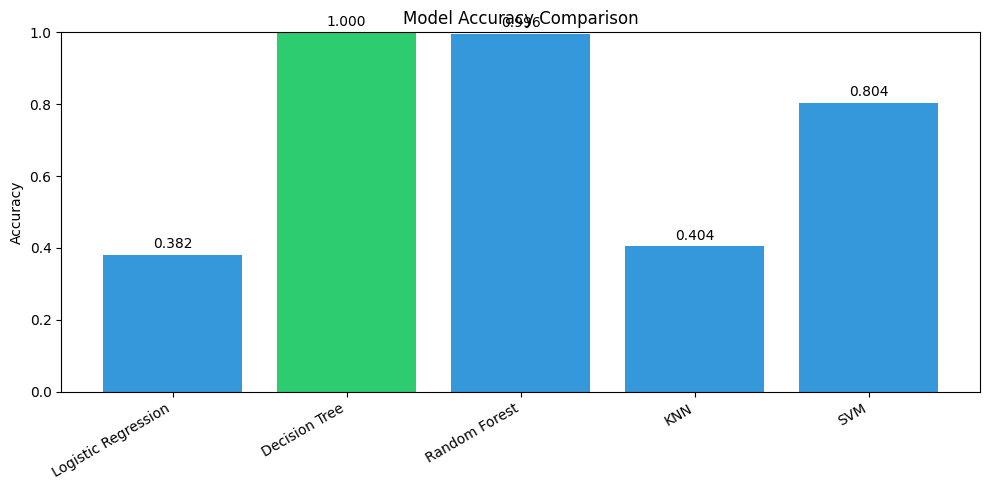

In [14]:
names  = list(results.keys())
values = list(results.values())

colors = ['#2ecc71' if n == best_model_name else '#3498db' for n in names]

plt.figure(figsize=(10, 5))
bars = plt.bar(names, values, color=colors)
plt.xticks(rotation=30, ha='right')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## Confusion Matrix for Best Model

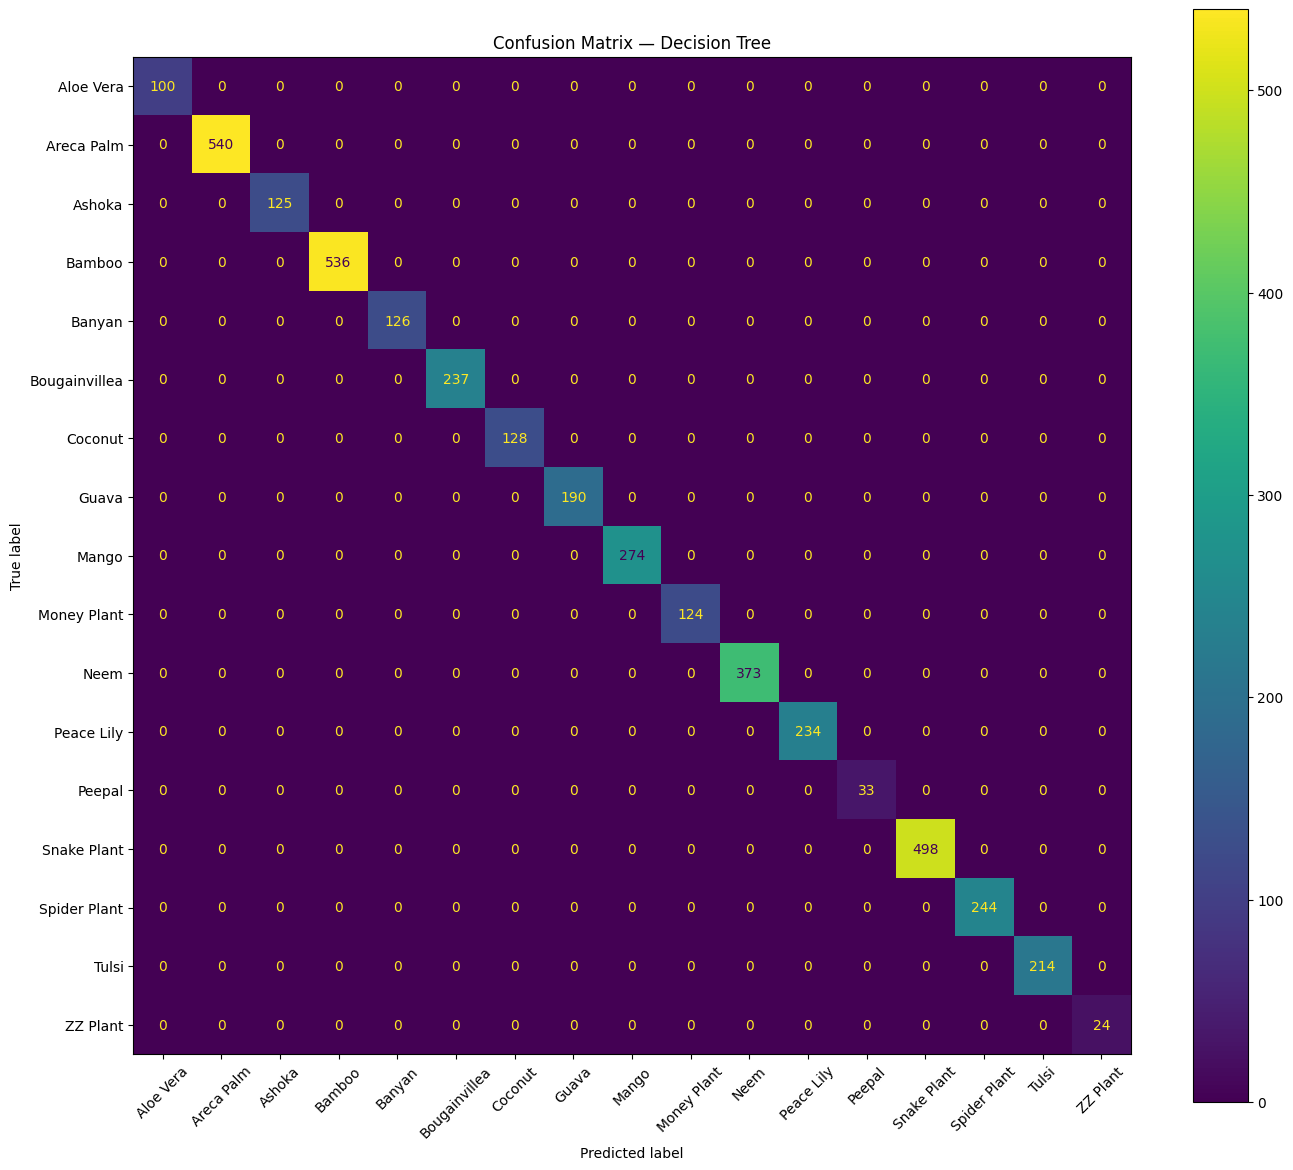

In [15]:
y_pred_best = best_model.predict(X_test)

fig, ax = plt.subplots(figsize=(14, 12))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=le_target.classes_,
    xticks_rotation=45,
    ax=ax
)
ax.set_title(f'Confusion Matrix — {best_model_name}')
plt.tight_layout()
plt.show()

## Save Best Model and Target Encoder

**Fix:** Save `le_target` (the correct target encoder) — not `le` from the feature encoding loop.

In [16]:
# FIX: save le_target — the correct encoder for the target column
joblib.dump(best_model, 'plant_model.pkl')
joblib.dump(le_target,  'label_encoder.pkl')

print(f'Saved: plant_model.pkl  ({best_model_name})')
print('Saved: label_encoder.pkl (target encoder)')

Saved: plant_model.pkl  (Decision Tree)
Saved: label_encoder.pkl (target encoder)


## Example Prediction

In [17]:
sample = pd.DataFrame([{
    'AreaType': 'Residential', 'AQI': 55, 'PM2.5': 22.0, 'PM10': 48.0,
    'NO2': 8.5, 'SO2': 5.0, 'CO': 0.30, 'O3': 65.0,
    'TrafficDensity': 'Low', 'RoadDistance': 90, 'DustIndex': 60,
    'Temperature': 28, 'Humidity': 70, 'Rainfall': 120, 'WindSpeed': 8,
    'Sunlight': 'Partial Shade', 'SoilType': 'Loamy', 'SoilPH': 6.5,
    'Drainage': 'Good', 'SpaceType': 'Indoor', 'AreaSize': 'Medium',
    'MaintenanceLevel': 'Low', 'WateringPreference': 'Regular',
    'Purpose': 'Decoration'
}])

pred_encoded = best_model.predict(sample)[0]
pred_label   = le_target.inverse_transform([pred_encoded])[0]

print('Recommended plant:', pred_label)

Recommended plant: Money Plant
